# Enhanced XGBoost Classifier for In-Hospital Mortality Prediction

This notebook trains an **enhanced XGBoost classifier** that augments the baseline
clinical feature set with an NLP-derived risk score from a fine-tuned language model.
The combined feature vector is used to predict in-hospital mortality (MIMIC-IV).

## Pipeline Overview
1. Load pre-processed clinical features and labels.
2. Integrate the NLP fine-tuned risk score as an additional feature.
3. Split data into stratified 80 / 20 train-test sets.
4. Train an XGBoost classifier with class-imbalance compensation.
5. Evaluate performance (AUC-ROC, F1, classification report).
6. Visualise the confusion matrix, ROC curve, and feature importances.
7. Optimise the classification threshold via the Precision-Recall curve.

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import os
import sys
sys.path.append('../core')
from config import processed_data_path, results_path
from model_func import save_model, save_report, save_figure
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, f1_score

## 2. Load Pre-Processed Clinical Features

Load the feature matrix `X`, binary label vector `y` (0 = Survivor, 1 = Mortality),
and feature names from `.npy` files produced by the preprocessing pipeline.

In [3]:
X_path = os.path.join(processed_data_path, 'X_data.npy')
y_path = os.path.join(processed_data_path, 'y_data.npy')
feature_names_path = os.path.join(processed_data_path, 'feature_names.npy')

X = np.load(X_path)
y = np.load(y_path)
feature_names = np.load(feature_names_path, allow_pickle=True)

## 3. Load NLP Fine-Tuned Risk Scores

Load the per-admission NLP risk scores generated by the fine-tuned clinical language model.
The CSV file maps each hospital admission (`hadm_id`) to a continuous risk score in [0, 1].

In [4]:
risk_scores_path = os.path.join(processed_data_path, 'nlp_finetuned_features.csv')
df_risk_scores = pd.read_csv(risk_scores_path)
df_risk_scores.head()

,hadm_id,nlp_finetuned_risk_score
0,27897940,0.571344
1,26913865,0.165627
2,24947999,0.157963
3,25242409,0.116425
4,25911675,0.236676


### 3a. Extract Risk Score Column

Isolate the `nlp_finetuned_risk_score` column and reshape it into a 2-D column
vector so it can be horizontally stacked onto the existing feature matrix.

In [5]:
risk_scores = df_risk_scores['nlp_finetuned_risk_score'].values.reshape(-1, 1)

### 3b. Augment Feature Matrix with NLP Score

Horizontally concatenate the NLP risk score to the clinical feature matrix
and update the feature-name list, producing the **final 22-feature input matrix**.

In [6]:
X_final = np.hstack((X, risk_scores))
feature_names_final = np.append(feature_names, 'nlp_finetuned_risk_score')

### 3c. Feature Set Summary

Print the total number of features in the augmented matrix and identify
column indices that correspond to NLP-derived features (prefix `nlp_`).

In [7]:
print(f"Final Feature Set: {X_final.shape[1]} features")

Final Feature Set: 22 features


In [8]:
nlp_indices = [i for i, name in enumerate(feature_names_final) if 'nlp_' in name]
print(nlp_indices)

[3, 4, 21]


## 4. Train / Test Split

Partition the augmented dataset into training (80 %) and test (20 %) sets.
`stratify=y` preserves the class distribution in both splits, which is critical
given the heavily imbalanced mortality labels.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

## 5. Define XGBoost Classifier

Instantiate `XGBClassifier` with:
- `scale_pos_weight=10` – compensates for the ~10:1 Survivor:Mortality imbalance.
- `eval_metric='logloss'` – log-loss evaluation during training.
- `random_state=42` – for reproducibility.

In [10]:
model = XGBClassifier(scale_pos_weight=10, eval_metric='logloss', use_label_encoder=False, random_state=42)

## 6. Train the Model

Fit the XGBoost classifier on the training split and persist the trained model
to disk via the project-level `save_model` utility.

In [11]:
model.fit(X_train, y_train)
save_model('XGBClassifier', model, "enhanced")

Model saved successfully at: E:\IIT\IRP\results\models\enhanced\XGBClassifier.joblib


c:\Users\damitha\.conda\envs\irp_gpu\lib\site-packages\xgboost\training.py:200: UserWarning: [17:56:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 7. Generate Predictions

Produce hard class predictions (`y_pred`) and probability scores (`y_prob`)
for the positive (Mortality) class on the held-out test set.

In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## 8. Compute Evaluation Metrics

Calculate:
- **AUC-ROC** – area under the receiver operating characteristic curve.
- **F1-Score** – harmonic mean of precision and recall for the minority class.
- **Classification Report** – per-class precision, recall, and F1.

In [13]:
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Survivor', 'Mortality'])

### 8a. Print and Save Metrics

Display evaluation results and persist the classification report to disk.

In [14]:
print(f"\nModel Performance: XGBClassifier")
print(f"AUC-ROC: {auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nClassification Report:")
print(report)
save_report('XGBClassifier', report, "enhanced", auc=auc, f1=f1)


Model Performance: XGBClassifier
AUC-ROC: 0.7706
F1-Score: 0.2817

Classification Report:
              precision    recall  f1-score   support

    Survivor       0.97      0.95      0.96      5269
   Mortality       0.24      0.34      0.28       267

    accuracy                           0.92      5536
   macro avg       0.60      0.64      0.62      5536
weighted avg       0.93      0.92      0.92      5536

Report saved successfully at: E:\IIT\IRP\results\metrics\enhanced\XGBClassifier.txt


## 9. Confusion Matrix

Plot and save a heatmap of the confusion matrix to visualise
TP, FP, TN, and FN counts.

Figure saved successfully at: E:\IIT\IRP\results\figures\enhanced/XGBoost\confusion_matrix_XGBoost.png


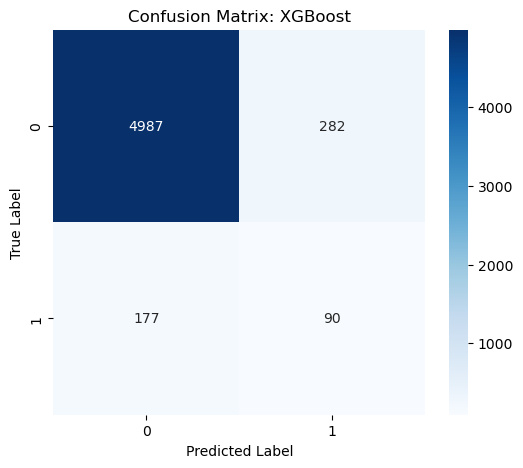

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig_cm, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix: XGBoost')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

save_figure('confusion_matrix', fig_cm, "enhanced/XGBoost", filename_suffix="XGBoost") # Save
plt.show()

## 10. ROC Curve

Plot and save the Receiver Operating Characteristic (ROC) curve.
The diagonal dashed line represents a random classifier (AUC = 0.5).

Figure saved successfully at: E:\IIT\IRP\results\figures\enhanced/XGBoost\ROC_Curve_XGBoost.png


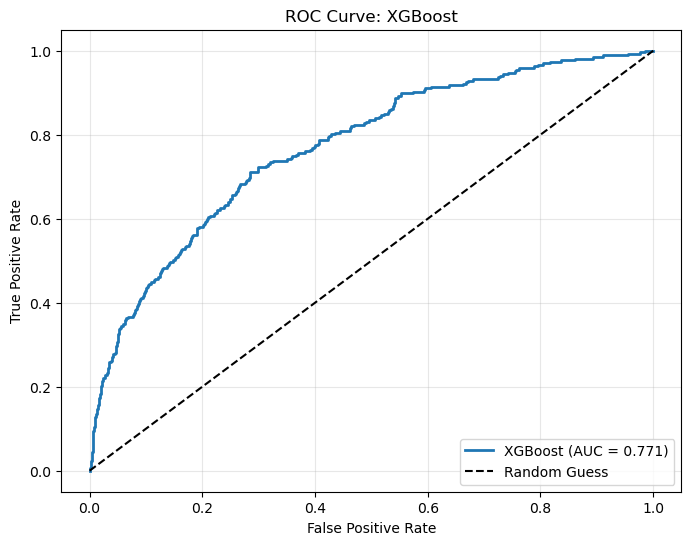

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig_roc, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f"XGBoost (AUC = {auc:.3f})", lw=2)
ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax.set_title(f'ROC Curve: XGBoost')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

save_figure('ROC_Curve', fig_roc, "enhanced/XGBoost", filename_suffix="XGBoost")
plt.show()

## 11. Threshold Optimisation

Use the Precision-Recall curve to find the threshold that maximises F1-score
on the test set. A standard 0.5 threshold is typically suboptimal for
heavily imbalanced datasets.

In [ ]:
from sklearn.metrics import precision_recall_curve

y_probs = model.predict_proba(X_test)[:, 1] 

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

fscore = (2 * precision * recall) / (precision + recall)
ix = np.argmax(fscore)
best_thresh = thresholds[ix]

print(f"Best Threshold: {best_thresh:.4f}")
print(f"Best F1-Score: {fscore[ix]:.4f}")

y_pred_new = (y_probs >= best_thresh).astype(int)

print("\n--- Optimized Classification Report ---")
print(classification_report(y_test, y_pred_new))

Best Threshold: 0.5038
Best F1-Score: 0.2830

--- Optimized Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      5269
           1       0.24      0.34      0.28       267

    accuracy                           0.92      5536
   macro avg       0.60      0.64      0.62      5536
weighted avg       0.93      0.92      0.92      5536



## 12. Feature Importances

Plot and save a bar chart of XGBoost feature importances (gain-based) to
identify which clinical and NLP features drive the predictions most.

Figure saved successfully at: E:\IIT\IRP\results\figures\enhanced/XGBoost\feat_impo_XGBoost.png


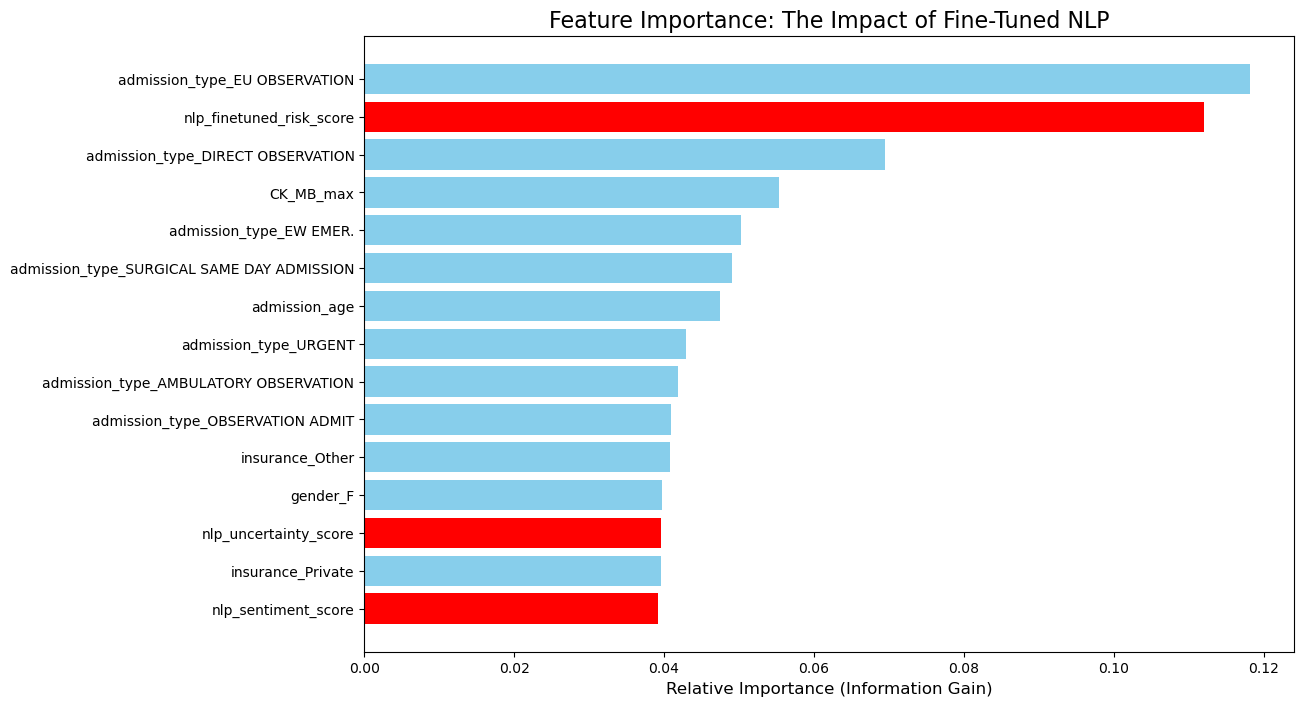

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

importance = model.feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names_final, 'importance': importance})

feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

fig_feat_imp = plt.figure(figsize=(12, 8))
colors = ['red' if 'nlp' in x else 'skyblue' for x in feat_imp['feature']]

plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors)
plt.gca().invert_yaxis()
plt.title("Feature Importance: The Impact of Fine-Tuned NLP", fontsize=16)
plt.xlabel("Relative Importance (Information Gain)", fontsize=12)
save_figure('feat_impo', fig_feat_imp, "enhanced/XGBoost", filename_suffix="XGBoost")
plt.show()

c:\Users\damitha\.conda\envs\irp_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating SHAP for 50 patients...


100%|██████████| 50/50 [00:00<00:00, 58.24it/s]


Detected Array output (50, 22, 2). Slicing [:, :, 1]...
Final SHAP Shape: (50, 22)
Final Data Shape: (50, 22)
Figure saved successfully at: E:\IIT\IRP\results\figures\enhanced/XGBoost\fig_shap_sum_XGBoost.png


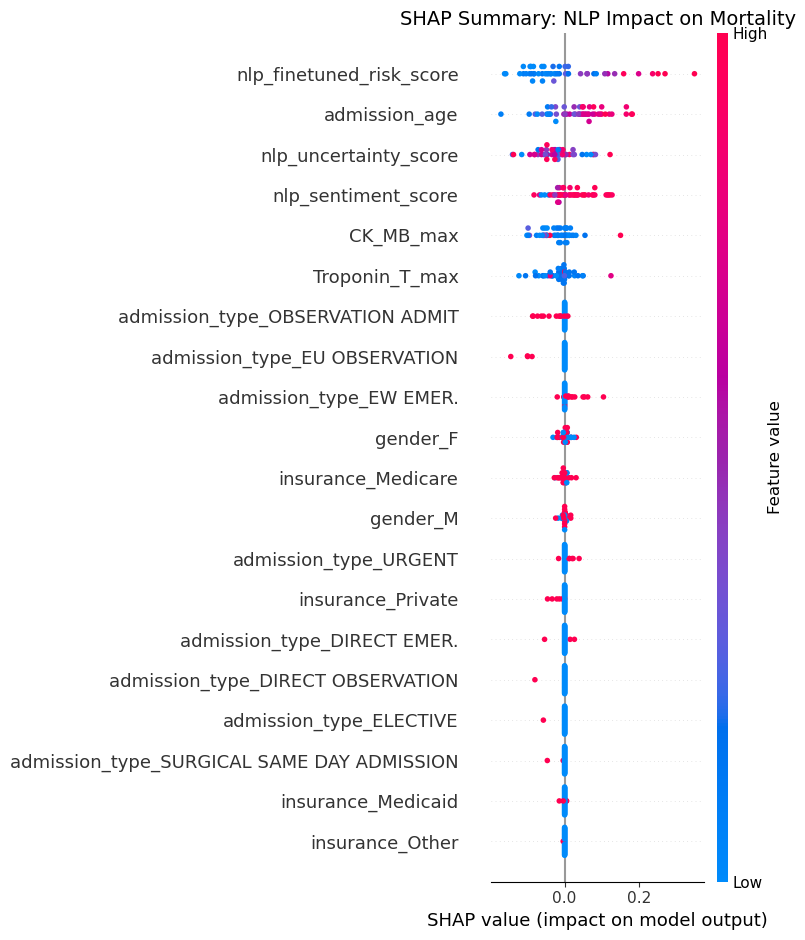


Generating Waterfall for Patient #41 (Risk: 0.7360)
Figure saved successfully at: E:\IIT\IRP\results\figures\enhanced/XGBoost\fig_explain_example_XGBoost.png


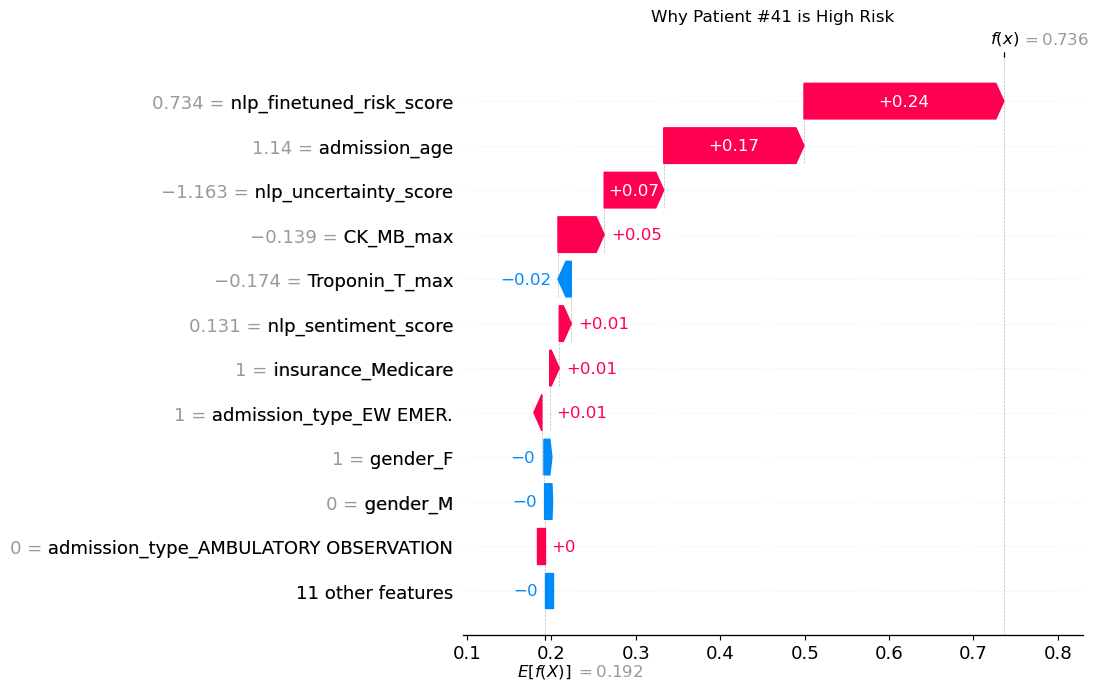

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

X_summary = shap.kmeans(X_train, 10) 
explainer = shap.KernelExplainer(model.predict_proba, X_summary)

num_patients = 50
print(f"Calculating SHAP for {num_patients} patients...")
shap_values_all = explainer.shap_values(X_test[:num_patients], nsamples=100)

if isinstance(shap_values_all, list):
    print("Detected List output. Extracting Index 1...")
    shap_values_death = shap_values_all[1]
else:
    print(f"Detected Array output {shap_values_all.shape}. Slicing [:, :, 1]...")
    shap_values_death = shap_values_all[:, :, 1]

print(f"Final SHAP Shape: {shap_values_death.shape}")
print(f"Final Data Shape: {X_test[:num_patients].shape}")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_death, X_test[:num_patients], feature_names=feature_names_final, show=False)
plt.title("SHAP Summary: NLP Impact on Mortality", fontsize=14)
plt.tight_layout()

fig_shap_sum = plt.gcf()
save_figure('fig_shap_sum', fig_shap_sum, "enhanced/XGBoost", filename_suffix="XGBoost")

plt.show()


probs = model.predict_proba(X_test[:num_patients])[:, 1]
high_risk_idx = np.argmax(probs)

print(f"\nGenerating Waterfall for Patient #{high_risk_idx} (Risk: {probs[high_risk_idx]:.4f})")

base_val = explainer.expected_value
if isinstance(base_val, np.ndarray) or isinstance(base_val, list):
    base_val = base_val[1]

exp = shap.Explanation(
    values=shap_values_death[high_risk_idx], 
    base_values=base_val, 
    data=X_test[high_risk_idx], 
    feature_names=feature_names_final
)

plt.figure(figsize=(8, 6))
shap.plots.waterfall(exp, max_display=12, show=False)
plt.title(f"Why Patient #{high_risk_idx} is High Risk")

fig_explain_example = plt.gcf()
save_figure('fig_explain_example', fig_explain_example, "enhanced/XGBoost", filename_suffix="XGBoost")

plt.show()